In [39]:
from sklearn.datasets import fetch_openml

titanic = fetch_openml("titanic", version=1, as_frame=True)
df = titanic.frame

In [40]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [41]:
print(df.shape)

(1309, 14)


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


In [43]:
df.describe()

,pclass,age,sibsp,parch,fare,body
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [44]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

Missing Values

In [45]:
df.isnull().sum().sort_values(ascending=False)

,0
body,1188
cabin,1014
boat,823
home.dest,564
age,263
embarked,2
fare,1
sibsp,0
name,0
survived,0


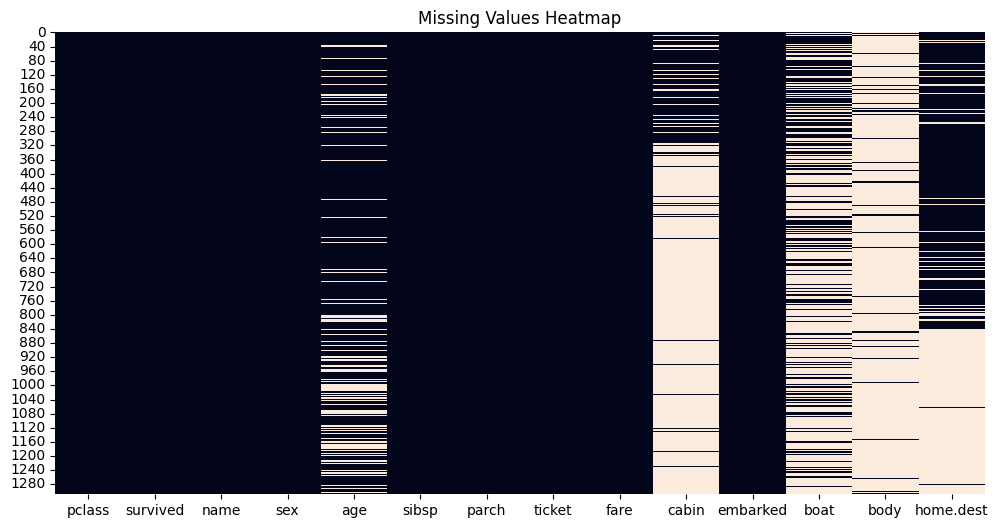

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [47]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
body,90.756303
cabin,77.463713
boat,62.872422
home.dest,43.086325
age,20.091673
embarked,0.152788
fare,0.076394
sibsp,0.000000
name,0.000000
survived,0.000000


In [48]:
df.drop(columns=["cabin", "boat", "body", "home.dest"], inplace=True)

In [49]:
df["age"] = df["age"].fillna(df["age"].median())

In [50]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [51]:
df["fare"] = df["fare"].fillna(df["fare"].median())

In [52]:
df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0
embarked,0


Duplicates

In [53]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [54]:
df.drop_duplicates(inplace=True)

print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates after cleaning: 0


In [55]:
df.dtypes

,0
pclass,int64
survived,category
name,object
sex,category
age,float64
sibsp,int64
parch,int64
ticket,object
fare,float64
embarked,category


In [56]:
categorical_cols = [
    "sex",
    "embarked",
    "pclass",
    "survived"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

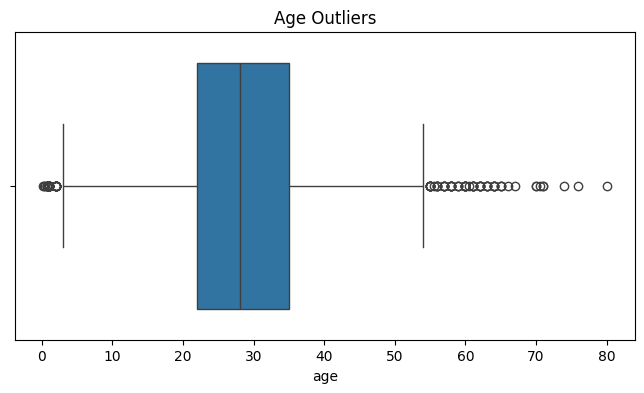

In [57]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["age"])
plt.title("Age Outliers")
plt.show()

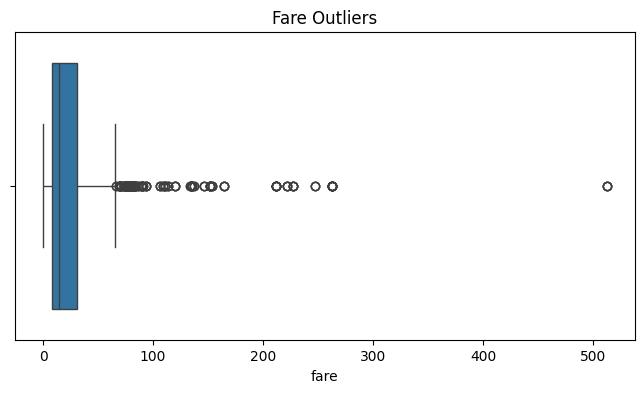

In [58]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["fare"])
plt.title("Fare Outliers")
plt.show()

In [59]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["fare"] < lower) | (df["fare"] > upper)]

print("Number of fare outliers:", len(outliers))

Number of fare outliers: 171


Data Visualization and Insights

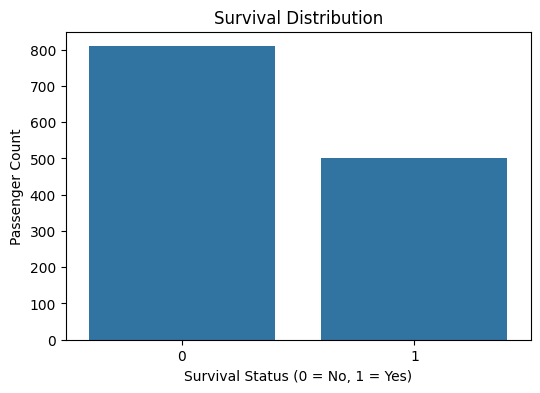

In [60]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='survived'
)

plt.title("Survival Distribution")
plt.xlabel("Survival Status (0 = No, 1 = Yes)")
plt.ylabel("Passenger Count")

plt.show()

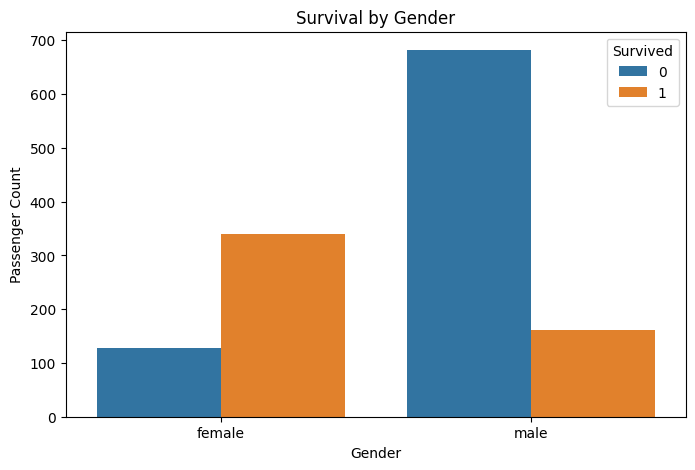

In [61]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='sex',
    hue='survived'
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")

plt.legend(title="Survived")

plt.show()

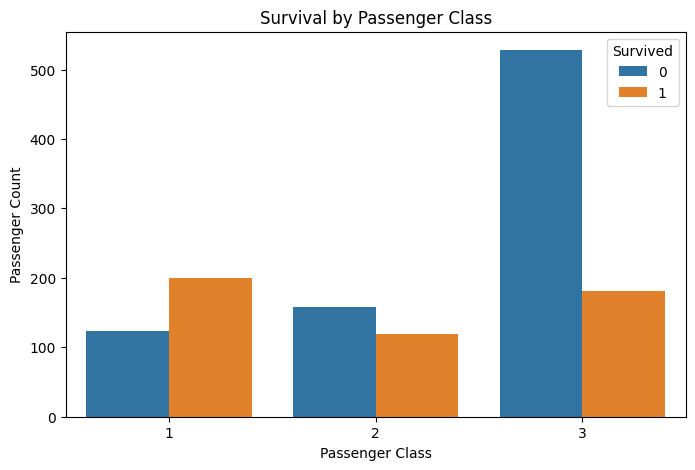

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='pclass',
    hue='survived'
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")

plt.legend(title="Survived")

plt.show()

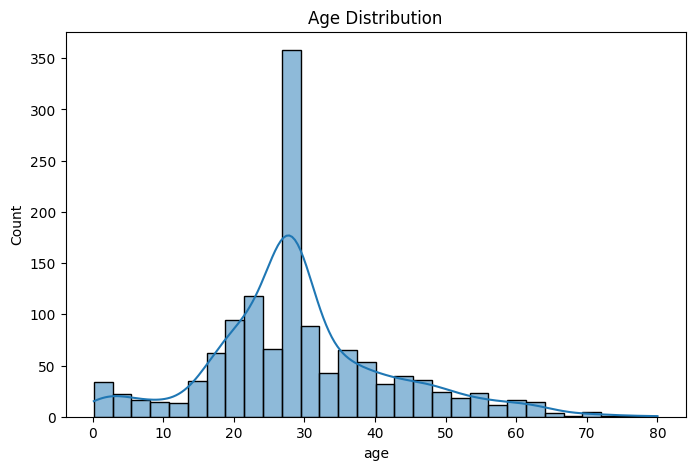

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

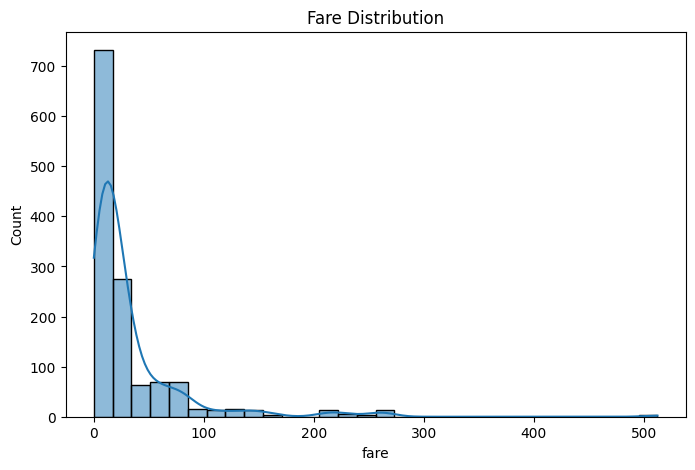

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["fare"],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.show()

In [65]:
numeric_df = df.select_dtypes(include=["number"])

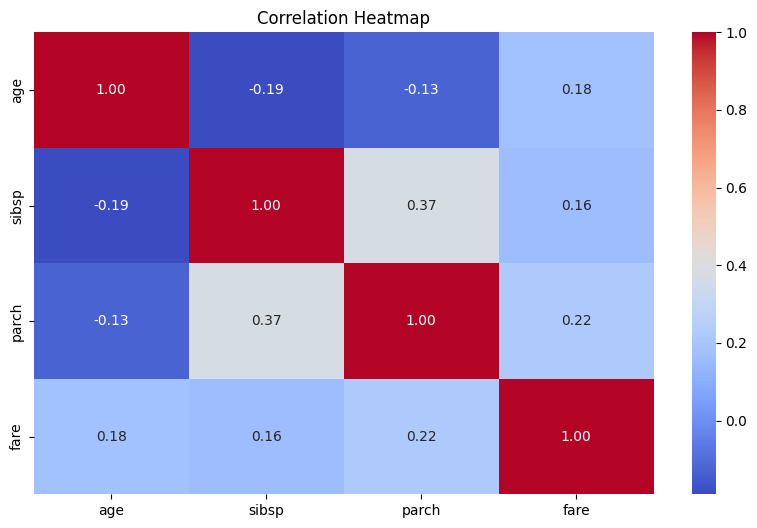

In [66]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

**Dashboard Summary**

A consolidated dashboard was created to provide an overview of key passenger characteristics and survival patterns. The dashboard combines multiple visualizations into a single view, enabling quick interpretation of the dataset and its major trends.

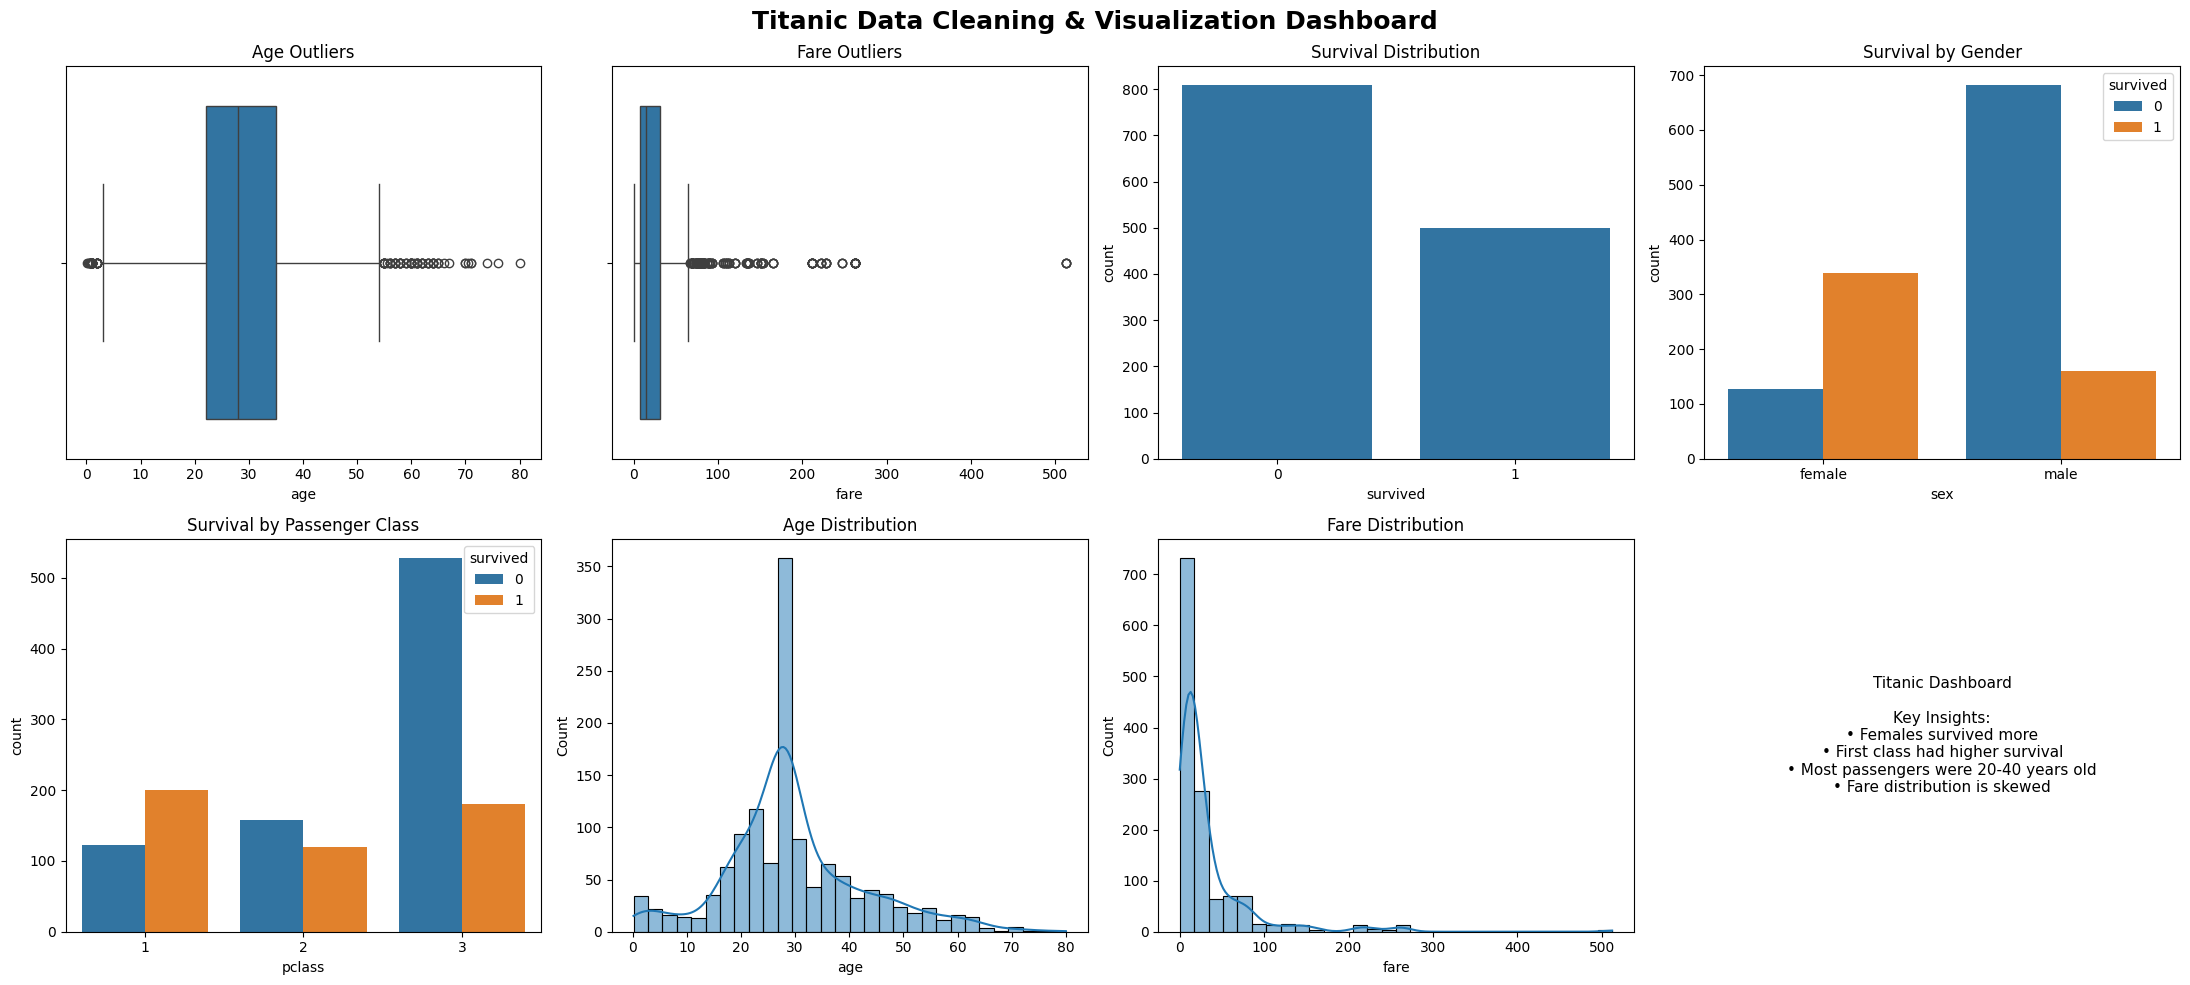

In [70]:
fig, axes = plt.subplots(2, 4, figsize=(22,10))

# Age Outliers
sns.boxplot(x=df["age"], ax=axes[0,0])
axes[0,0].set_title("Age Outliers")

# Fare Outliers
sns.boxplot(x=df["fare"], ax=axes[0,1])
axes[0,1].set_title("Fare Outliers")

# Survival Distribution
sns.countplot(
    data=df,
    x="survived",
    ax=axes[0,2]
)
axes[0,2].set_title("Survival Distribution")

# Survival by Gender
sns.countplot(
    data=df,
    x="sex",
    hue="survived",
    ax=axes[0,3]
)
axes[0,3].set_title("Survival by Gender")

# Survival by Passenger Class
sns.countplot(
    data=df,
    x="pclass",
    hue="survived",
    ax=axes[1,0]
)
axes[1,0].set_title("Survival by Passenger Class")

# Age Distribution
sns.histplot(
    df["age"],
    bins=30,
    kde=True,
    ax=axes[1,1]
)
axes[1,1].set_title("Age Distribution")

# Fare Distribution
sns.histplot(
    df["fare"],
    bins=30,
    kde=True,
    ax=axes[1,2]
)
axes[1,2].set_title("Fare Distribution")

# Summary Panel
axes[1,3].axis("off")
axes[1,3].text(
    0.5,
    0.5,
    "Titanic Dashboard\n\nKey Insights:\n• Females survived more\n• First class had higher survival\n• Most passengers were 20-40 years old\n• Fare distribution is skewed",
    ha="center",
    va="center",
    fontsize=11
)

plt.suptitle(
    "Titanic Data Cleaning & Visualization Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()